<a href="https://colab.research.google.com/github/DianaDoosti-PouyanBahmani/Intelligent-Systems/blob/main/mini%20project%203/MINI3-Q5%266.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading the Dataset

In [ ]:
!pip install -q gdown
import gdown
import pandas as pd

file_id_train = "1gzjgqinJIiRcyFsk1C3yQJzwvaxjXRZ3"
output = "Titanic_dataset.csv"

url = f"https://drive.google.com/uc?id={file_id_train}"
gdown.download(url, output, quiet=False, fuzzy=True)

df = pd.read_csv(output)
df.head()

Downloading...
From: https://drive.google.com/uc?id=1gzjgqinJIiRcyFsk1C3yQJzwvaxjXRZ3
To: /content/Titanic_dataset.csv
100%|██████████| 61.2k/61.2k [00:00<00:00, 43.7MB/s]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Preprocessing

In [ ]:
# Drop useless columns
df = df.drop(columns=["Name", "Ticket", "Cabin"])

# Check for missing data
missing_report = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df)) * 100
})
missing_report[missing_report["missing_count"] > 0]

,column,missing_count,missing_percentage
Age,Age,177,19.865320
Embarked,Embarked,2,0.224467


In [ ]:
# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median()) # median (robust to outliers)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0]) # mode (most frequent value)

# One-hot encoding
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Decision Tree Classifier

##Helper Funcion for Defining the model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def train_and_evaluate_tree(max_depth, X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Tree properties
    n_nodes = model.tree_.node_count
    depth = model.tree_.max_depth

    print(f"Max depth: {max_depth}")
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Test accuracy:  {test_acc:.4f}")
    print(f"Number of nodes: {n_nodes}")
    print(f"Actual depth:   {depth}")
    print("-" * 40)

    return train_acc, test_acc

## max_depth = 4 vs max_depth = NONE

In [ ]:
depths = [4, None]

train_accuracies = []
test_accuracies = []

for d in depths:
    train_acc, test_acc = train_and_evaluate_tree(
        d, X_train, X_test, y_train, y_test
    )
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

Max depth: 4
Train accuracy: 0.8371
Test accuracy:  0.7989
Number of nodes: 29
Actual depth:   4
----------------------------------------
Max depth: None
Train accuracy: 1.0000
Test accuracy:  0.7207
Number of nodes: 289
Actual depth:   17
----------------------------------------


## depths = [3, 5, 10, None]

In [ ]:
depths = [3, 5, 10, None]

train_accuracies = []
test_accuracies = []

for d in depths:
    train_acc, test_acc = train_and_evaluate_tree(
        d, X_train, X_test, y_train, y_test
    )
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

Max depth: 3
Train accuracy: 0.8343
Test accuracy:  0.7989
Number of nodes: 15
Actual depth:   3
----------------------------------------
Max depth: 5
Train accuracy: 0.8596
Test accuracy:  0.7989
Number of nodes: 49
Actual depth:   5
----------------------------------------
Max depth: 10
Train accuracy: 0.9508
Test accuracy:  0.7821
Number of nodes: 197
Actual depth:   10
----------------------------------------
Max depth: None
Train accuracy: 1.0000
Test accuracy:  0.7207
Number of nodes: 289
Actual depth:   17
----------------------------------------


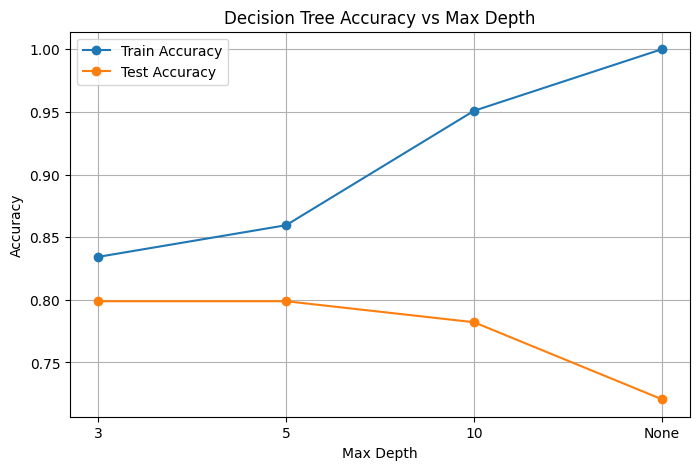

In [ ]:
import matplotlib.pyplot as plt

depth_labels = [3, 5, 10, "None"]

plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_accuracies, marker='o', label="Train Accuracy")
plt.plot(depth_labels, test_accuracies, marker='o', label="Test Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Max Depth")
plt.legend()
plt.grid(True)
plt.show()

#Cost-Complexity Pruning

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[ccp_alphas > 0]

In [ ]:
from sklearn.metrics import accuracy_score

train_accs = []
test_accs = []
node_counts = []
depths = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )
    clf.fit(X_train, y_train)

    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))
    node_counts.append(clf.tree_.node_count)
    depths.append(clf.tree_.max_depth)

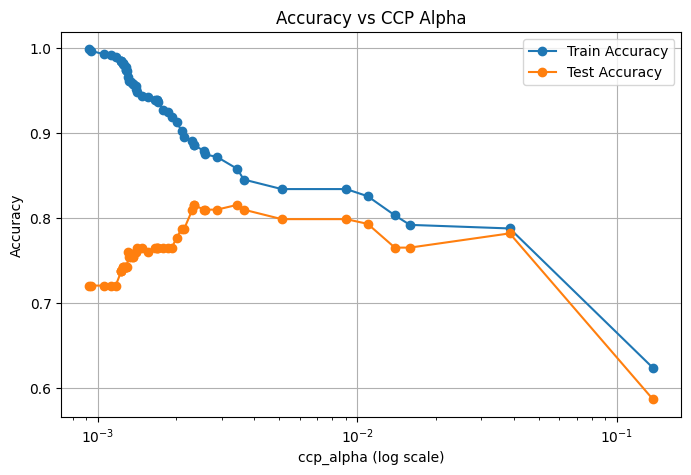

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, train_accs, marker='o', label="Train Accuracy")
plt.plot(ccp_alphas, test_accs, marker='o', label="Test Accuracy")

plt.xscale("log")
plt.xlabel("ccp_alpha (log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs CCP Alpha")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

ccp_alphas_np = np.array(ccp_alphas)

threshold = 1e-2
valid_alphas = ccp_alphas_np[ccp_alphas_np < threshold]

best_alpha = valid_alphas.max()
print("Selected alpha:", best_alpha)
print("Next alpha:", ccp_alphas_np[ccp_alphas_np > best_alpha].min())

Selected alpha: 0.009055400380113265
Next alpha: 0.010948672114402452


In [ ]:
pruned_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

pruned_tree.fit(X_train, y_train)

# Predictions
y_train_pred = pruned_tree.predict(X_train)
y_test_pred = pruned_tree.predict(X_test)

# Accuracies
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Pruned Tree (ccp_alpha =", best_alpha, ")")
print("Train accuracy:", round(train_acc, 4))
print("Test accuracy: ", round(test_acc, 4))

print("Number of nodes:", pruned_tree.tree_.node_count)
print("Actual depth:  ", pruned_tree.tree_.max_depth)

Pruned Tree (ccp_alpha = 0.009055400380113265 )
Train accuracy: 0.8343
Test accuracy:  0.7989
Number of nodes: 11
Actual depth:   3
